## 1. Предварительная проверка данных

Перед тем как отвечать на исследовательские вопросы, важно сначала понять, что именно содержится в данных. Все найденные проблемы будут учтены на этапе очистки данных и напрямую повлияют на правила обработки в следующем разделе (2).

**Об источнике данных.** Оба файла построены на основе open-source базы LiteLLM model price & context window database из репозитория BerriAI LiteLLM GitHub repository. База содержит информацию о ценах на AI-модели, размерах контекстного окна и других характеристиках моделей, поддерживаемых различными LLM-провайдерами.

Для восстановления динамики изменения цен использовалась полная история изменений Git-репозитория, на основе которой были построены еженедельные снимки (weekly snapshots). Данные актуальны на 29 сентября 2026 года.

Исходные данные были дополнительно обработаны и расширены автором датасета Abiram Bharathi S.A.

**Основные особенности данных**:
- **Цены представлены как публичные list prices в USD** для стандартного использования API. Они не включают индивидуальные корпоративные скидки, специальные тарифы /тарифы для больших объёмов потребления
-  Поле `first_listed_week` отражает дату появления модели в базе данных, а не официальную дату релиза модели. Обычно эти события происходят близко друг к другу, но возможна задержка между запуском API и добавлением записи в базу
- Изменения цен в истории могут отражать не только реальные изменения стоимости API, но и **исправления ранее внесенных ошибок** в исходных данных
- Информация о разработчике модели и стране происхождения была определена с помощью правил сопоставления названий. Для части моделей источник не позволяет однозначно определить эти параметры; такие записи относятся к категории "Other"
- Одна и та же модель может встречаться несколько раз, если она доступна через разных провайдеров, регионы или варианты размещения API. Такие записи сохраняются намеренно, поскольку стоимость и условия использования могут различаться


**Лицензирование**

Исходные данные LiteLLM предоставлены проектом Berri AI и распространяются под лицензией MIT License (Copyright © 2023 Berri AI). Производный датасет также распространяется в соответствии с условиями MIT License.

In [68]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

# Settings used throughout the notebook
TEXT_MODES = ["chat", "responses"]
INPUT_WEIGHT = 0.90        # взвешенная цена = 90% input токены + 10% output токены (по данным от Cursor)
CORRECTION_RATIO = 10      # a one-step change of 10x or more = data correction
BULK_MIN_CHANGES = 5       # 5+ changes by one provider in one week = batch week

FIRST_PARTY = {
    "OpenAI": ["openai"],
    "Anthropic": ["anthropic"],
    "Google": ["gemini", "vertex_ai", "vertex_ai-language-models"],
    "Meta": ["meta", "meta_llama"],
    "DeepSeek": ["deepseek"],
    "Mistral AI": ["mistral", "codestral"],
    "xAI": ["xai"],
    "Alibaba": ["dashscope", "qwen_ai_platform", "qwencloud"],
    "Moonshot AI": ["moonshot"],
    "Zhipu AI (Z.ai)": ["zai"],
    "MiniMax": ["minimax"],
    "Cohere": ["cohere", "cohere_chat"],
    "Perplexity": ["perplexity"],
    "AI21 Labs": ["ai21"],
    "Amazon": ["amazon_nova", "bedrock", "bedrock_converse"],
    "Xiaomi": ["xiaomi_mimo"],
    "ByteDance": ["volcengine"],
    "Tencent": ["tencent"],
}

### 1.1 Обзор

In [4]:
hist_raw = pd.read_csv("/Users/annaefremenko/Desktop/Workspace/my projects/ai models/ai-model-pricing-analysis-/data/ai_model_price_history.csv", parse_dates=["week_start"])
snap_raw = pd.read_csv("/Users/annaefremenko/Desktop/Workspace/my projects/ai models/ai-model-pricing-analysis-/data/ai_models_2026.csv", parse_dates=["first_listed_week"])

In [6]:
print("Snapshot (ai_models_2026):", snap_raw.shape[0], "rows x", snap_raw.shape[1], "columns")
print("Price history (ai_model_price_history):", hist_raw.shape[0], "rows x", hist_raw.shape[1], "columns")
print()
print("History covers", hist_raw["week_start"].nunique(), "weeks:",
      hist_raw["week_start"].min().date(), "to", hist_raw["week_start"].max().date())

Snapshot (ai_models_2026): 4403 rows x 31 columns
Price history (ai_model_price_history): 167787 rows x 9 columns

History covers 157 weeks: 2023-09-18 to 2026-09-28


In [7]:
snap_raw.head(3).T

,0,1,2
model_id,fireworks_ai/accounts/fireworks/models/llava-y...,fireworks_ai/accounts/fireworks/models/yi-34b,fireworks_ai/accounts/fireworks/models/yi-34b-...
model_name,llava-yi-34b,yi-34b,yi-34b-200k-capybara
developer,01.AI,01.AI,01.AI
developer_country,China,China,China
provider,fireworks_ai,fireworks_ai,fireworks_ai
mode,chat,chat,chat
input_price_per_1m_tokens,0.9,0.9,0.9
output_price_per_1m_tokens,0.9,0.9,0.9
cached_input_price_per_1m_tokens,NaN,NaN,NaN
batch_input_price_per_1m_tokens,NaN,NaN,NaN


In [8]:
hist_raw.head(3)

,week_start,model_id,model_name,developer,provider,mode,input_price_per_1m_tokens,output_price_per_1m_tokens,max_input_tokens
0,2024-09-23,accounts/fireworks/models/llama-v3p2-90b-visio...,llama-v3p2-90b-vision-instruct,Meta,fireworks_ai,chat,0.9,0.9,16384.0
1,2024-09-30,accounts/fireworks/models/llama-v3p2-90b-visio...,llama-v3p2-90b-vision-instruct,Meta,fireworks_ai,chat,0.9,0.9,16384.0
2,2024-10-07,accounts/fireworks/models/llama-v3p2-90b-visio...,llama-v3p2-90b-vision-instruct,Meta,fireworks_ai,chat,0.9,0.9,16384.0


**Что означает одна строка в файле?**
- Snapshot: одна строка представляет собой одну комбинацию «модель × провайдер» на текущий момент. Например, модель DeepSeek-R1, доступная через провайдера Fireworks
- History: одна строка представляет собой одну комбинацию «модель × провайдер × неделя наблюдения». Ниже мы проверим, что для каждой такой комбинации существует только одна запись на каждую неделю

In [9]:
print("Duplicate model_id in snapshot:", snap_raw["model_id"].duplicated().sum())
print("Duplicate (model_id, week) in history: ", hist_raw.duplicated(["model_id", "week_start"]).sum())

Duplicate model_id in snapshot: 0
Duplicate (model_id, week) in history:  0


### 1.2 Словарь по типам колонок в данных

In [10]:
dictionary = pd.DataFrame({
    "type": snap_raw.dtypes.astype(str),
    "missing_%": (snap_raw.isna().mean() * 100).round(1),
    "unique_values": snap_raw.nunique(),
    "example": snap_raw.iloc[0],
})
dictionary

,type,missing_%,unique_values,example
model_id,object,0.0,4403,fireworks_ai/accounts/fireworks/models/llava-y...
model_name,object,0.0,2265,llava-yi-34b
developer,object,0.0,51,01.AI
developer_country,object,0.0,12,China
provider,object,0.0,133,fireworks_ai
mode,object,0.0,14,chat
input_price_per_1m_tokens,float64,17.1,328,0.9
output_price_per_1m_tokens,float64,17.4,392,0.9
cached_input_price_per_1m_tokens,float64,62.1,214,NaN
batch_input_price_per_1m_tokens,float64,91.7,55,NaN


### 1.3 Пропущенные значения

Пропуски в ценовых полях являются ожидаемыми для тех параметров, которые применимы только к определенным типам моделей. Например, ожидается, что колонка `price_per_image` будет заполнена только для моделей, работающих с изображениями, и будет отсутствовать для текстовых моделей

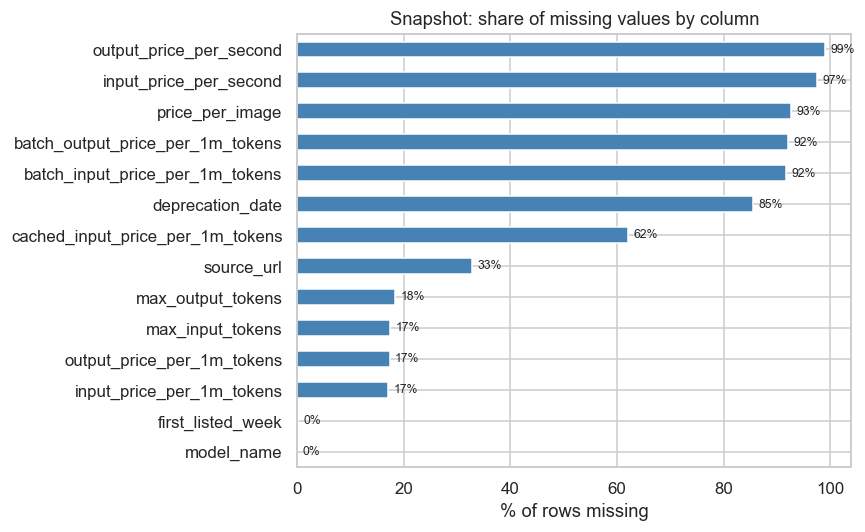

In [11]:
missing = (snap_raw.isna().mean() * 100).sort_values()
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(8, 5))
missing.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("% of rows missing")
ax.set_title("Snapshot: share of missing values by column")
for i, v in enumerate(missing):
    ax.text(v + 1, i, f"{v:.0f}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

In [12]:
# Характерны ли пропуски данных для НЕ текстовых моделей?
price_by_mode = snap_raw.groupby("mode").agg(
    listings=("model_id", "size"),
    share_with_token_price=("input_price_per_1m_tokens", lambda s: s.notna().mean()),
)
price_by_mode.round(2).sort_values("listings", ascending=False)

,listings,share_with_token_price
mode,,
chat,3340,0.96
image_generation,405,0.14
embedding,148,0.94
responses,143,0.84
audio_transcription,93,0.15
realtime,51,0.92
video_generation,45,0.00
audio_speech,40,0.38
completion,34,0.97


**Анализ пропущенных значений**

- **Цены за токены и размер контекстного окна (около 17% пропусков в целом, около 5% среди текстовых моделей).**  
  Модели для работы с изображениями, видео и аудио, как правило, тарифицируются по количеству изображений или времени использования (например, за секунду), поэтому поля с ценами за токены для них отсутствуют по определению.  Среди текстовых моделей около 5% записей не имеют указанной цены, а ещё примерно 3% содержат значение `$0`, используемое как placeholder. Таким образом, около **92% текстовых моделей пригодны для анализа стоимости**.

- **Цены за кешированные токены и batch-обработку (62% и 92% пропусков соответственно).**  
  Эти параметры представляют собой дополнительные скидочные механизмы. Пустое значение может означать как отсутствие такой опции у провайдера, так и то, что информация не была внесена в базу. Полнота данных сильно различается между провайдерами.  
  В рамках данного анализа эти поля **не используются**.

- **Цены за изображение и секунду использования (93–99% пропусков).**  
  Эти параметры применимы только к моделям, работающим с изображениями, видео и аудио. Высокая доля пропусков является ожидаемой и не считается проблемой качества данных.

- **`deprecation_date` (85% пропусков).**  
  Пустое значение означает, что дата вывода модели из эксплуатации не была объявлена. Это является нормальной ситуацией для большинства активных моделей.

- **`source_url` (33% пропусков).**  
  Это вспомогательное поле, содержащее ссылки на документацию. Оно используется только для справочных целей и не влияет на результаты анализа.

- **Флаги возможностей модели (0% пропусков, но потенциально вводящие в заблуждение).**  
  Несмотря на отсутствие пропущенных значений, эти поля требуют осторожной интерпретации. Значение `False` часто означает не то, что функция действительно не поддерживается моделью, а то, что информация о ней не была заполнена в базе данных.  
  Это является **одной из наиболее существенных скрытых проблем качества данных**.
  



  ### 3.4 Какие типы моделей есть в данных?

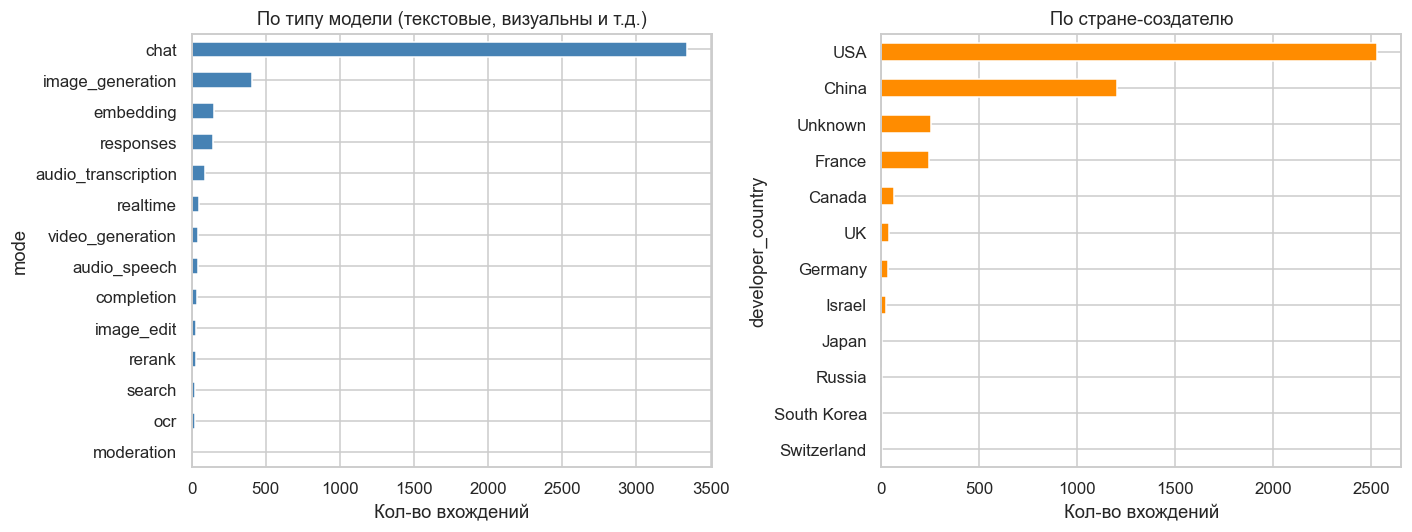

Текстовые модели (chat + responses): 79% всего датасета


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

snap_raw["mode"].value_counts().plot.barh(ax=axes[0], color="steelblue")
axes[0].invert_yaxis()
axes[0].set_title("По типу модели (текстовые, визуальны и т.д.)")
axes[0].set_xlabel("Кол-во вхождений")

snap_raw["developer_country"].value_counts().plot.barh(ax=axes[1], color="darkorange")
axes[1].invert_yaxis()
axes[1].set_title("По стране-создателю")
axes[1].set_xlabel("Кол-во вхождений")

plt.tight_layout()
plt.show()

text_share = snap_raw["mode"].isin(TEXT_MODES).mean()
print(f"Текстовые модели (chat + responses): {text_share:.0%} всего датасета")

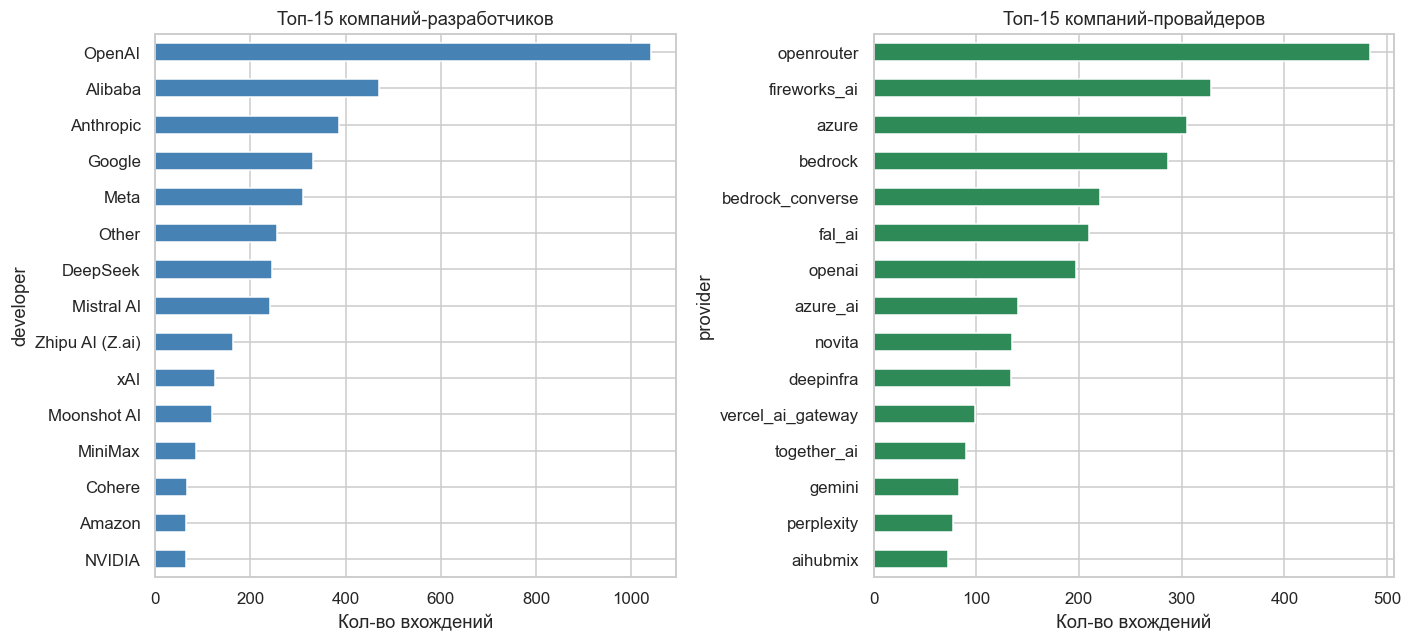

Компании-разрабочики: 51 | Компании-провайдеры: 133
Кол-во строк с не указанной компанией-разработчиком ('Other'): 5.8%


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

top_dev = snap_raw["developer"].value_counts().head(15)
top_dev.plot.barh(ax=axes[0], color="steelblue")
axes[0].invert_yaxis()
axes[0].set_title("Топ-15 компаний-разработчиков")
axes[0].set_xlabel("Кол-во вхождений")

top_prov = snap_raw["provider"].value_counts().head(15)
top_prov.plot.barh(ax=axes[1], color="seagreen")
axes[1].invert_yaxis()
axes[1].set_title("Топ-15 компаний-провайдеров")
axes[1].set_xlabel("Кол-во вхождений")

plt.tight_layout()
plt.show()

print("Компании-разрабочики:", snap_raw["developer"].nunique(), "| Компании-провайдеры:", snap_raw["provider"].nunique())
print("Кол-во строк с не указанной компанией-разработчиком ('Other'):", f"{(snap_raw['developer'] == 'Other').mean():.1%}")

### 1.5 Цены токенов

Начиная с этого этапа, анализ будет сосредоточен на **текстовых моделях**, поскольку исследовательские вопросы связаны с динамикой цен за токены.

Цены на AI-модели могут значительно отличаться, поэтому для визуализации используется логарифмическая шкала. Она позволяет корректно отображать как бюджетные, так и наиболее дорогие модели на одном графике и лучше сравнивать распределение цен.

In [15]:
text = snap_raw[snap_raw["mode"].isin(TEXT_MODES)].copy()

print("Всего строк для текстовых моделей:", len(text))
print("Строки с нулевой ценой (=$0): ", (text["input_price_per_1m_tokens"] == 0).sum())
print("Строки с пропущеной ценой:", text["input_price_per_1m_tokens"].isna().sum())

text[["input_price_per_1m_tokens", "output_price_per_1m_tokens"]].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]
).round(2)

Всего строк для текстовых моделей: 3483
Строки с нулевой ценой (=$0):  107
Строки с пропущеной ценой: 167


,input_price_per_1m_tokens,output_price_per_1m_tokens
count,3316.00,3320.00
mean,1.96,8.77
std,6.09,27.00
min,0.00,0.00
10%,0.07,0.18
25%,0.18,0.50
50%,0.60,1.80
75%,1.96,7.51
90%,4.00,20.00
max,150.00,600.00


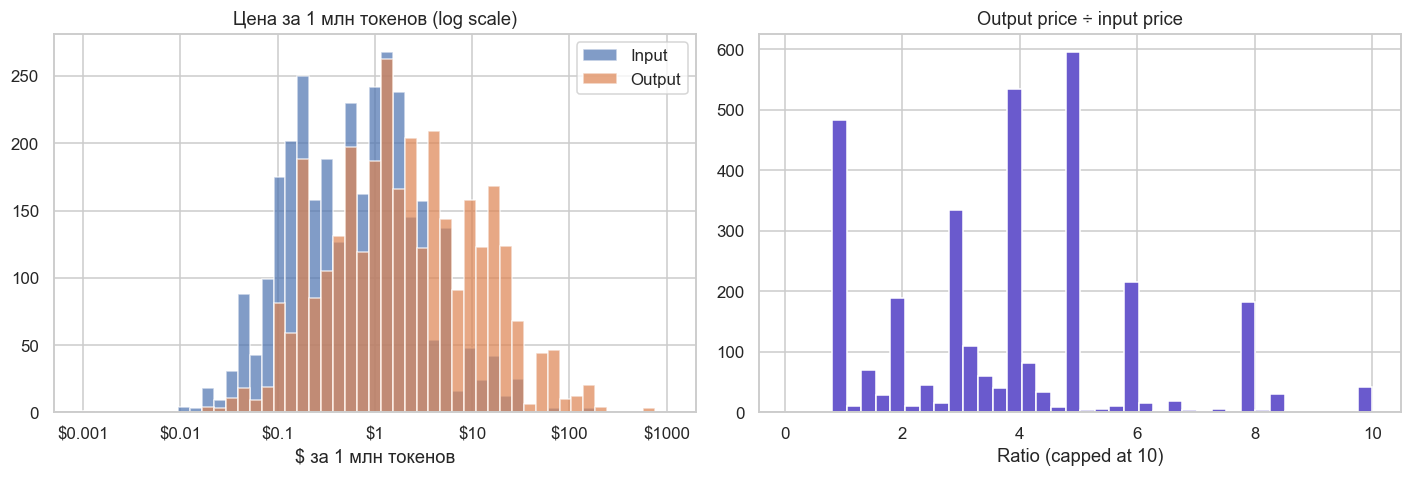

Медианное соотношение output/input цен: 4.0
Доля строк, где output цена = input цене: 15%


In [17]:
priced = text[(text["input_price_per_1m_tokens"] > 0) & (text["output_price_per_1m_tokens"] > 0)].copy()
bins = np.logspace(-3, 3, 50)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(priced["input_price_per_1m_tokens"], bins=bins, alpha=0.7, label="Input")
axes[0].hist(priced["output_price_per_1m_tokens"], bins=bins, alpha=0.7, label="Output")
axes[0].set_xscale("log")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:g}"))
axes[0].set_title("Цена за 1 млн токенов (log scale)")
axes[0].set_xlabel("$ за 1 млн токенов")
axes[0].legend()

priced["out_in_ratio"] = priced["output_price_per_1m_tokens"] / priced["input_price_per_1m_tokens"]
axes[1].hist(priced["out_in_ratio"].clip(upper=10), bins=40, color="slateblue")
axes[1].set_title("Output price ÷ input price")
axes[1].set_xlabel("Ratio (capped at 10)")

plt.tight_layout()
plt.show()

print("Медианное соотношение output/input цен:", round(priced["out_in_ratio"].median(), 1))
print("Доля строк, где output цена = input цене:", f"{(priced['out_in_ratio'] == 1).mean():.0%}")

In [18]:
# Самые дорогие и самые дешевые текстовые модели
cheapest_listing = priced.sort_values("input_price_per_1m_tokens").drop_duplicates(["model_name", "developer"])
cols = ["model_name", "developer", "provider", "input_price_per_1m_tokens", "output_price_per_1m_tokens"]

print("Самые дорогие:")
display(cheapest_listing.nlargest(8, "input_price_per_1m_tokens")[cols])
print("Самые дешевые:")
display(cheapest_listing.nsmallest(8, "input_price_per_1m_tokens")[cols])

Самые дорогие:


,model_name,developer,provider,input_price_per_1m_tokens,output_price_per_1m_tokens
3383,o1-pro,OpenAI,openai,150.0,600.0
3385,o1-pro-2025-03-19,OpenAI,openai,150.0,600.0
2762,gpt-4.5-preview,OpenAI,azure,75.0,150.0
2715,gpt-4-32k,OpenAI,azure,60.0,120.0
2716,gpt-4-32k-0613,OpenAI,azure,60.0,120.0
3059,gpt-5.5-pro-2026-04-23,OpenAI,openai,30.0,180.0
3032,gpt-5.4-pro-2026-03-05,OpenAI,openai,30.0,180.0
2705,gpt-4,OpenAI,azure,30.0,60.0


Самые дешевые:


,model_name,developer,provider,input_price_per_1m_tokens,output_price_per_1m_tokens
978,flux-1-dev-controlnet-union,Black Forest Labs,fireworks_ai,0.0010,0.001
56,Qwen2.5-Coder-7B-Instruct,Alibaba,nscale,0.0100,0.030
55,Qwen2.5-Coder-7B,Alibaba,nebius,0.0100,0.030
54,Qwen2.5-Coder-3B-Instruct,Alibaba,nscale,0.0100,0.030
2594,nemotron-3.5-lightning-30b-a3b,NVIDIA,perplexity,0.0115,0.170
3294,gpt-oss-20b,OpenAI,darkbloom,0.0145,0.070
1989,llama3.2-11b-vision-instruct,Meta,lambda_ai,0.0150,0.025
1992,llama3.2-3b-instruct,Meta,lambda_ai,0.0150,0.025


### 1.6 Контекстное окно

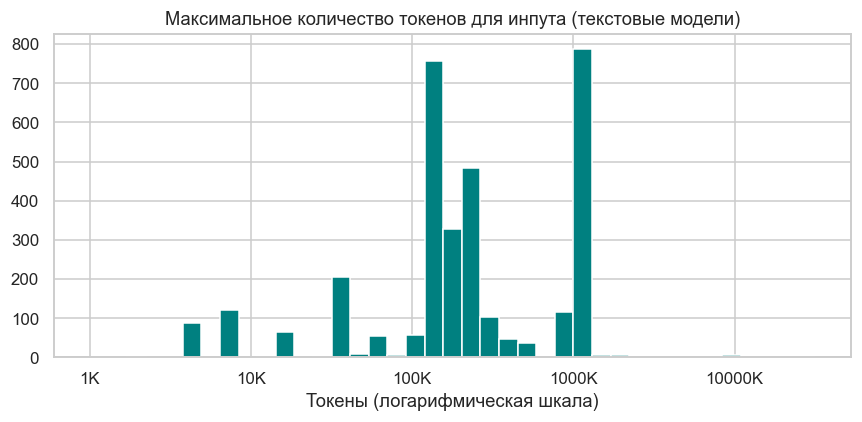

count        3299.0
mean       413485.0
std        556469.0
min           512.0
10%         32000.0
25%        128000.0
50%        200000.0
75%        997952.0
90%       1048576.0
max      10485760.0
Name: max_input_tokens, dtype: float64

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(text["max_input_tokens"].dropna(), bins=np.logspace(3, 7.5, 40), color="teal")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:g}K"))
ax.set_title("Максимальное количество токенов для инпута (текстовые модели)")
ax.set_xlabel("Токены (логарифмическая шкала)")
plt.tight_layout()
plt.show()

text["max_input_tokens"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(0)

### 1.7 Флаги возможностей моделей


В датасете есть 12 булевых (`true/false`) признаков, которые описывают возможности каждой модели.

**Важно:** в этой базе данных значение флага устанавливается пользователем, который добавляет запись о модели. Поэтому значение `False` может означать как:

- функция действительно **не поддерживается моделью**;
- информация об этой возможности **просто не была заполнена**.

Таким образом, эти признаки необходимо интерпретировать с осторожностью, поскольку отсутствие отметки не всегда означает отсутствие функциональности.

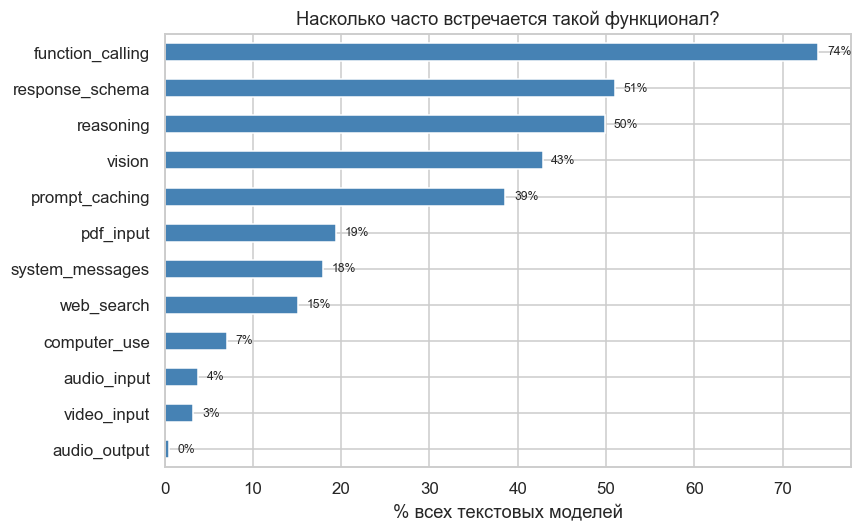

In [20]:
flag_cols = [c for c in snap_raw.columns if c.startswith("supports_")]
flag_share = (text[flag_cols].mean() * 100).sort_values()
flag_share.index = flag_share.index.str.replace("supports_", "")

fig, ax = plt.subplots(figsize=(8, 5))
flag_share.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("% всех текстовых моделей")
ax.set_title("Насколько часто встречается такой функционал?")
for i, v in enumerate(flag_share):
    ax.text(v + 1, i, f"{v:.0f}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

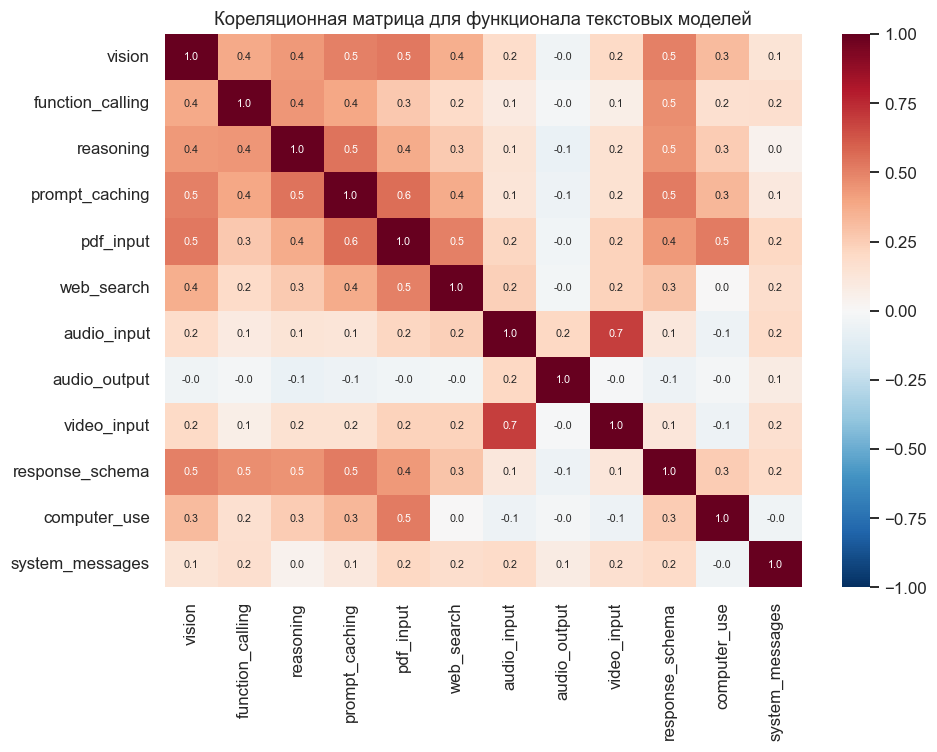

In [21]:
# Какие врзможности чаще встречаются вместе?
corr = text[flag_cols].astype(int).corr()
corr.index = corr.columns = [c.replace("supports_", "") for c in flag_cols]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".1f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={"size": 7})
ax.set_title("Кореляционная матрица для функционала текстовых моделей")
plt.tight_layout()
plt.show()

In [22]:
# Одинаково ли размечены возможности моделей у разных провайдеров? На примере модели DeepSeek-R1
example = text[text["model_name"] == "deepseek-r1"]
example[["provider", "input_price_per_1m_tokens", "supports_reasoning", "supports_function_calling", "supports_vision"]]

,provider,input_price_per_1m_tokens,supports_reasoning,supports_function_calling,supports_vision
1218,azure_ai,1.35,False,False,False
1219,deepseek,0.55,True,True,False
1220,fireworks_ai,3.00,False,False,False
1221,novita,4.00,True,True,False
1222,openrouter,0.70,True,True,False
1223,replicate,3.75,True,False,False
1224,snowflake,1.35,True,False,False
1225,vercel_ai_gateway,0.55,False,False,False


DeepSeek-R1 - reasoning-модель по своей архитектуре, однако 3 из 8 провайдеров, через которых она доступна, указывают значение `supports_reasoning = False`.

В рамках этого датасета значение `False` часто означает не отсутствие поддержки функциональности, а то, что информация о ней **не была заполнена**. При этом часть различий может быть реальной: например, провайдер может не включать поддержку вызова функций (`function calling`) для конкретного варианта развертывания модели.

Однако по имеющимся данным невозможно однозначно определить, какой из этих случаев имеет место. Если все провайдеры указывают одинаковое значение (например, `vision = False`), вероятность того, что этот признак корректен, выше.

Одна и та же модель также может иметь существенно разную стоимость в зависимости от провайдера. Например, цена DeepSeek-R1 варьируется от **$0.55 до $4.00 за 1 млн входных токенов** в зависимости от хоста — почти в **7 раз** при использовании одинаковых весов модели.

**Выводы для дальнейшего анализа**

- Сравнение цен на основе отдельных строк с флагами возможностей может частично отражать не реальные различия в стоимости функций моделей, а то, насколько тщательно разные провайдеры заполняют информацию о возможностях (RQ2)

- Поэтому в дальнейшем при аггрегации функций на уровне модели, функционал считается поддерживаемым, если **хотя бы один провайдер указывает его наличие**

- Значительные различия в стоимости одной и той же модели у разных провайдеров становятся основой для дальнейшего исследования ценовой вариативности (RQ5)

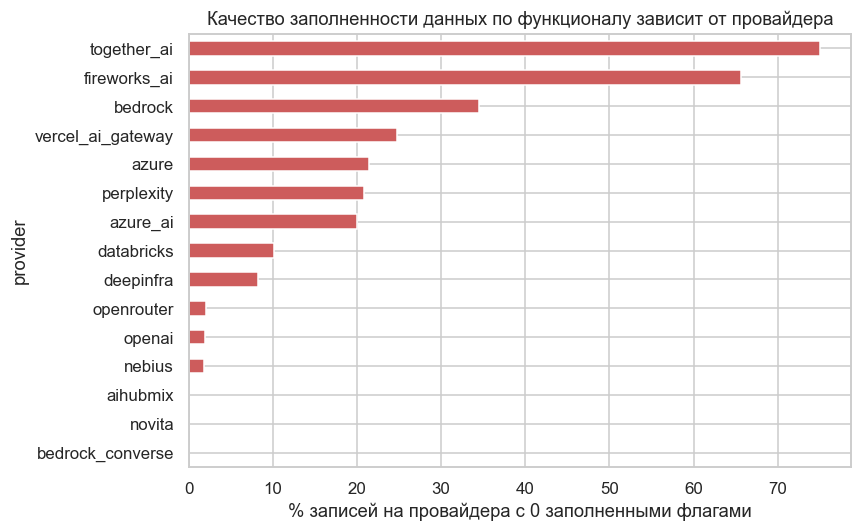

In [23]:
# Доля строк с незаполненными полями по функциональности (топ 15 провайдеров)
text["n_flags"] = text[flag_cols].sum(axis=1)
no_flags = (
    text.groupby("provider")["n_flags"]
    .agg(listings="size", share_no_flags=lambda s: (s == 0).mean())
    .sort_values("listings", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(8, 5))
(no_flags["share_no_flags"] * 100).sort_values().plot.barh(ax=ax, color="indianred")
ax.set_xlabel("% записей на провайдера с 0 заполненными флагами")
ax.set_title("Качество заполненности данных по функционалу зависит от провайдера")
plt.tight_layout()
plt.show()

### 1.8 Одна модель -- множество провайдеров

In [24]:
hosts_per_model = text.groupby(["model_name", "developer"])["provider"].nunique()

print("Model name + developer groups:", len(hosts_per_model))
print("Served by 2+ providers:", (hosts_per_model > 1).sum())
print()
print("Самые популярные у провайдеров модели:")
print(hosts_per_model.sort_values(ascending=False).head(8).to_string())

Model name + developer groups: 1766
Served by 2+ providers: 507

Самые популярные у провайдеров модели:
model_name              developer      
gpt-oss-120b            OpenAI             20
deepseek-v4-flash       DeepSeek           13
gpt-oss-20b             OpenAI             12
deepseek-v4-pro         DeepSeek           10
kimi-k2.7-code          Moonshot AI         9
glm-5.2                 Zhipu AI (Z.ai)     9
deepseek-r1             DeepSeek            8
Llama-3.3-70B-Instruct  Meta                8


In [25]:
# Иногда одна и та же модель может по-разному называться у разных провайдеров. Например, Llama 3.3 70B может называться "llama-3.3-70b", "llama-3.3-70B", "llama-3.3-70B-chat", "llama-3.3-70B-instruct" и т.д.:
llama_names = text.loc[text["model_name"].str.contains("llama.?3.?3.?70b", case=False, regex=True), "model_name"]
print("Spellings of Llama 3.3 70B:", llama_names.nunique())
print(sorted(llama_names.unique()))

Spellings of Llama 3.3 70B: 19
['Llama-3.3-70B-Instruct', 'Llama-3.3-70B-Instruct-Turbo', 'Meta-Llama-3.3-70B-Instruct', 'Meta-Llama-3_3-70B-Instruct', 'databricks-meta-llama-3-3-70b-instruct', 'deepseek-llama3.3-70b', 'dobby-unhinged-llama-3-3-70b-new', 'llama-3-3-70b-instruct', 'llama-3.3-70b', 'llama-3.3-70b-instruct', 'llama-3.3-70b-instruct-fp8-fast', 'llama-3.3-70b-instruct-maas', 'llama3.3-70b', 'llama3.3-70b-instruct', 'llama3.3-70b-instruct-fp8', 'meta.llama-3.3-70b-instruct', 'meta.llama-3.3-70b-instruct-fp8-dynamic', 'meta.llama3-3-70b-instruct-v1:0', 'snowflake-llama-3.3-70b']


In [26]:
# Одна и та же модель может иметь разные цены у разных провайдеров (напримере Deepseek R1)
example_hosts = (
    priced[priced["model_name"] == "deepseek-r1"]
    .sort_values("input_price_per_1m_tokens")
    [["provider", "input_price_per_1m_tokens", "output_price_per_1m_tokens"]]
)
example_hosts

,provider,input_price_per_1m_tokens,output_price_per_1m_tokens
1219,deepseek,0.55,2.19
1225,vercel_ai_gateway,0.55,2.19
1222,openrouter,0.70,2.50
1218,azure_ai,1.35,5.40
1224,snowflake,1.35,5.40
1220,fireworks_ai,3.00,8.00
1223,replicate,3.75,10.00
1221,novita,4.00,4.00


### 1.9 Временное покрытие

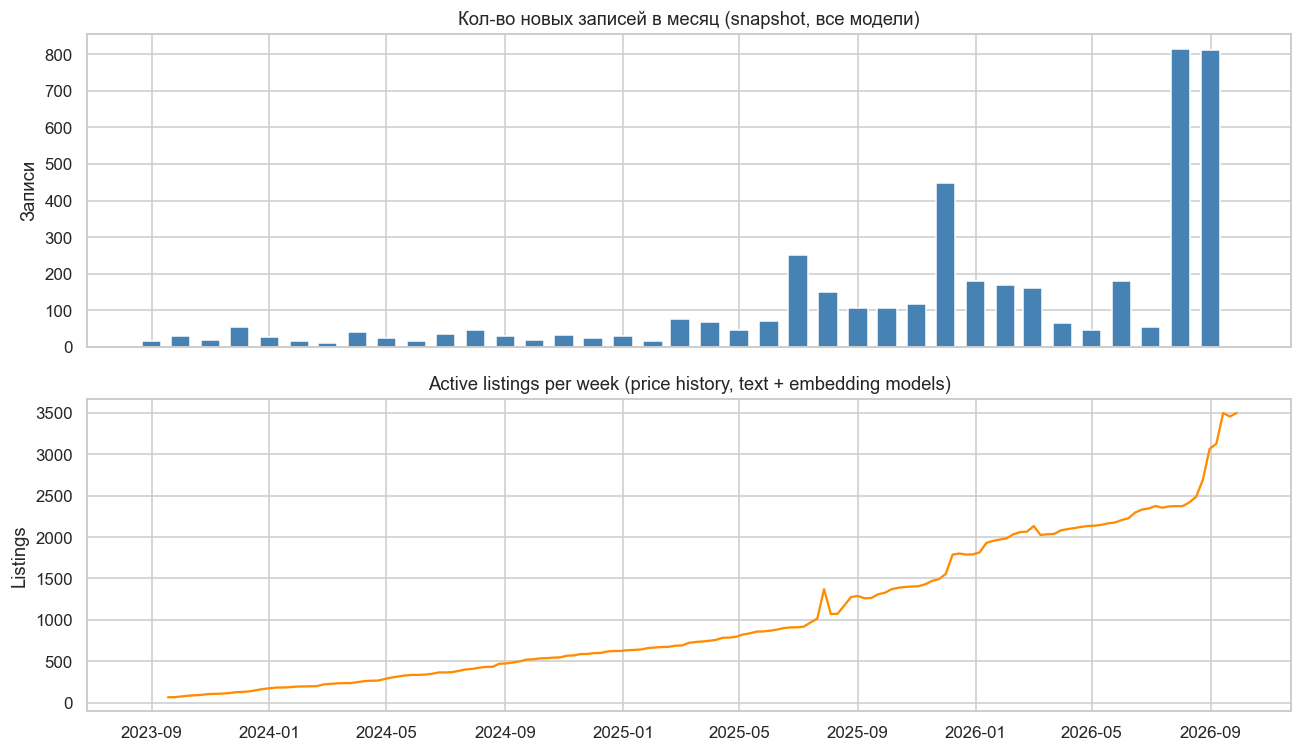

Biggest single weeks of new listings:
first_listed_week
2026-08-31    391
2026-09-14    361
2026-09-21    340
2025-12-08    258
2026-08-24    240


In [27]:
added_per_month = snap_raw.set_index("first_listed_week").resample("MS").size()
active_per_week = hist_raw.groupby("week_start")["model_id"].nunique()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].bar(added_per_month.index, added_per_month.values, width=20, color="steelblue")
axes[0].set_title("Кол-во новых записей в месяц (snapshot, все модели)")
axes[0].set_ylabel("Записи")

axes[1].plot(active_per_week.index, active_per_week.values, color="darkorange")
axes[1].set_title("Active listings per week (price history, text + embedding models)")
axes[1].set_ylabel("Listings")

plt.tight_layout()
plt.show()

print("Biggest single weeks of new listings:")
print(snap_raw["first_listed_week"].value_counts().head(5).to_string())

Резкие скачки на сотни новых записей за одну неделю не означают, что за этот период было выпущено сотни новых моделей. Такие всплески, скорее всего, связаны с добавлением в базу нового провайдера или массовым заполнением ранее отсутствующих данных.

Поэтому для анализа, связанного с датами запуска моделей, будет использоваться дата, когда модель впервые появилась в API своего разработчика, а не дата добавления записи в базу данных.

Кроме того, модели, которые уже присутствовали в базе данных в первую неделю наблюдения, имеют неизвестную фактическую дату запуска. Такие наблюдения цензурированны слева: мы видим модель уже после ее появления, но не знаем, сколько времени прошло с момента реального запуска.

In [28]:
first_seen = hist_raw.groupby("model_id")["week_start"].min()
print("Записи, которое уже пристутсвовали на неделю 1 (дата запуска неизвестна):", (first_seen == hist_raw["week_start"].min()).sum())

# Мэтчатся ли first_listed_week с первой неделей из истории?
check = snap_raw.merge(first_seen.rename("first_in_history"), left_on="model_id", right_index=True)
gap_days = (check["first_listed_week"] - check["first_in_history"]).dt.days
print("first_listed_week равна первой неделе в истории:", f"{(gap_days == 0).mean():.0%} of matched listings")

Записи, которое уже пристутсвовали на неделю 1 (дата запуска неизвестна): 65
first_listed_week равна первой неделе в истории: 99% of matched listings


### 1.10 Как связаны два файла?

In [29]:
snap_ids = set(snap_raw["model_id"])
hist_ids = set(hist_raw["model_id"])

print("Записи, доступные в 2х файлах:     ", len(snap_ids & hist_ids))
print("Есть только в истории (делистинг): ", len(hist_ids - snap_ids))
print("Только в snapshot:           ", len(snap_ids - hist_ids))
print()
print("Модели, представленные только в снэпшоте по типам:")
print(snap_raw[snap_raw["model_id"].isin(snap_ids - hist_ids)]["mode"].value_counts().head(6).to_string())

Записи, доступные в 2х файлах:      3535
Есть только в истории (делистинг):  762
Только в snapshot:            868

Модели, представленные только в снэпшоте по типам:
mode
image_generation       404
chat                   137
audio_transcription     93
video_generation        45
audio_speech            39
image_edit              31


Записи, которые присутствуют только в историческом датасете и отсутствуют в текущем срезе данных, были **удалены из основной базы**. Это, как правило, модели, которые были выведены из использования (`deprecated models`).

Если бы анализ изменения цен проводился только на основе текущего snapshot-файла, мы бы учитывали только модели, которые сохранились на сегодняшний день. В результате анализ был бы смещен в сторону «выживших» моделей и не отражал бы полную динамику рынка.

Поэтому для анализа изменения цен необходимо использовать **исторический файл (`history`)**, который содержит информацию о моделях и их ценах за весь период наблюдения.

### 1.11 Изменения цен в истории

In [30]:
h = hist_raw[hist_raw["mode"].isin(TEXT_MODES)].sort_values(["model_id", "week_start"]).copy()
h["prev_in"] = h.groupby("model_id")["input_price_per_1m_tokens"].shift(1)

changes = h[h["prev_in"].notna() & (h["input_price_per_1m_tokens"] != h["prev_in"])].copy()
changes["direction"] = np.where(changes["input_price_per_1m_tokens"] < changes["prev_in"], "сокращение", "рост")

print("Изменения цен инпут-токенов за 3 года:", len(changes))
print(changes["direction"].value_counts().to_string())
print()
print("Строки с ценой $0:", (h["input_price_per_1m_tokens"] == 0).sum(),
      "across", h.loc[h["input_price_per_1m_tokens"] == 0, "model_id"].nunique(), "listings")

Изменения цен инпут-токенов за 3 года: 614
direction
сокращение    338
рост          276

Строки с ценой $0: 7325 across 217 listings


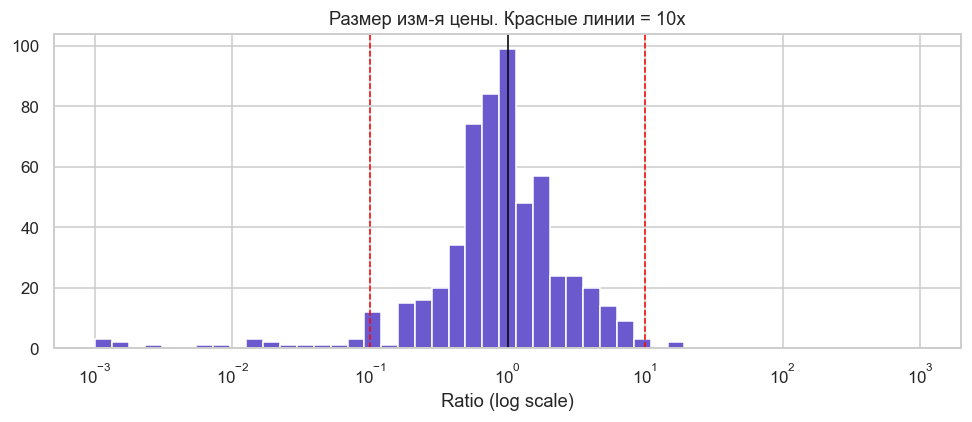

Изменения в 10x и больше: 39


In [31]:
# Насколько это большие изменения? (ratio = новая цена / старая цена)
valid = changes[(changes["prev_in"] > 0) & (changes["input_price_per_1m_tokens"] > 0)].copy()
valid["ratio"] = valid["input_price_per_1m_tokens"] / valid["prev_in"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(valid["ratio"], bins=np.logspace(-3, 3, 50), color="slateblue")
ax.set_xscale("log")
ax.axvline(1, color="black", lw=1)
ax.axvline(CORRECTION_RATIO, color="red", ls="--", lw=1)
ax.axvline(1 / CORRECTION_RATIO, color="red", ls="--", lw=1)
ax.set_title("Размер изм-я цены. Красные линии = 10x")
ax.set_xlabel("Ratio (log scale)")
plt.tight_layout()
plt.show()

print("Изменения в 10x и больше:", ((valid["ratio"] >= 10) | (valid["ratio"] <= 0.1)).sum())

In [32]:
# Примеры изменений цен, которые, вероятно, являются исправлениями, а не реальными сдвигами в прайсинге
valid[(valid["ratio"] >= 10) | (valid["ratio"] <= 0.1)].sort_values("week_start")[
    ["week_start", "model_id", "provider", "prev_in", "input_price_per_1m_tokens"]
].head(12)

,week_start,model_id,provider,prev_in,input_price_per_1m_tokens
36493,2023-11-20,claude-instant-1.2,anthropic,1.63,0.163000
34837,2024-02-12,chatdolphin,nlp_cloud,20.00,0.500000
155136,2024-05-27,vertex_ai/claude-3-opus@20240229,vertex_ai-anthropic_models,1.50,15.000000
74184,2024-07-01,gemini/gemini-1.5-pro,gemini,0.35,3.500000
74600,2024-07-01,gemini/gemini-1.5-pro-latest,gemini,0.35,3.500000
41444,2024-09-09,command-light,cohere_chat,15.00,0.300000
70221,2024-10-07,gemini-1.5-flash-exp-0827,vertex_ai-language-models,0.50,0.004688
70697,2024-10-07,gemini-1.5-pro-preview-0215,vertex_ai-language-models,5.00,0.078125
70797,2024-10-07,gemini-1.5-pro-preview-0409,vertex_ai-language-models,5.00,0.078125
70892,2024-10-07,gemini-1.5-pro-preview-0514,vertex_ai-language-models,5.00,0.078125


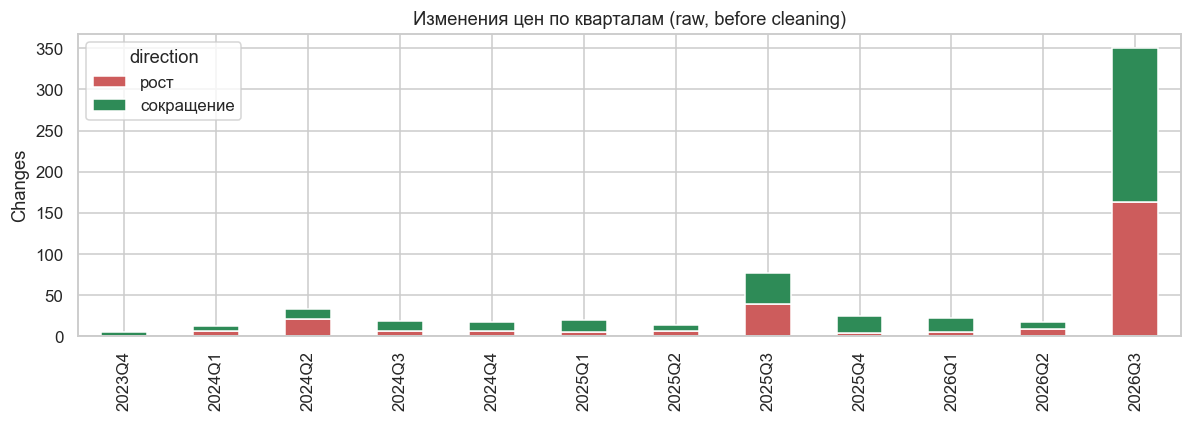

Доля всех изменений в 2026Q3: 57%


In [33]:
# Price changes per quarter
changes["quarter"] = changes["week_start"].dt.to_period("Q").astype(str)
per_quarter = changes.groupby(["quarter", "direction"]).size().unstack(fill_value=0)

ax = per_quarter.plot.bar(stacked=True, figsize=(11, 4), color={"сокращение": "seagreen", "рост": "indianred"})
ax.set_title("Изменения цен по кварталам (raw, before cleaning)")
ax.set_xlabel("")
ax.set_ylabel("Changes")
plt.tight_layout()
plt.show()

last_q = per_quarter.index.max()
print(f"Доля всех изменений в {last_q}: {per_quarter.loc[last_q].sum() / per_quarter.values.sum():.0%}")

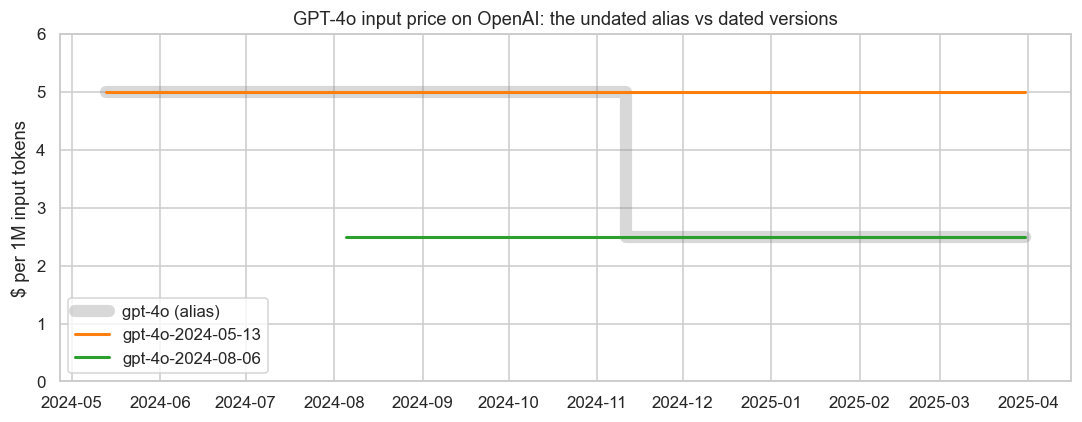

In [34]:
# The GPT-4o "price cut"
gpt4o = h[(h["provider"] == "openai") & h["model_name"].isin(["gpt-4o", "gpt-4o-2024-05-13", "gpt-4o-2024-08-06"])]
gpt4o_wide = gpt4o.pivot(index="week_start", columns="model_name", values="input_price_per_1m_tokens")

gpt4o_wide = gpt4o_wide.loc["2024-05":"2025-03"]

fig, ax = plt.subplots(figsize=(10, 4))

ax.step(gpt4o_wide.index, gpt4o_wide["gpt-4o"], where="post", lw=8, alpha=0.3, color="grey", label="gpt-4o (alias)")
ax.step(gpt4o_wide.index, gpt4o_wide["gpt-4o-2024-05-13"], where="post", lw=2, color="tab:orange", label="gpt-4o-2024-05-13")
ax.step(gpt4o_wide.index, gpt4o_wide["gpt-4o-2024-08-06"], where="post", lw=2, color="tab:green", label="gpt-4o-2024-08-06")
ax.set_ylim(0, 6)
ax.legend(loc="lower left")
ax.set_title("GPT-4o input price on OpenAI: the undated alias vs dated versions")
ax.set_ylabel("$ per 1M input tokens")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

Недатированная запись модели `gpt-4o` показывает снижение цены с **$5 до $2.50** в ноябре 2024 года. Однако анализ версий с указанием дат показывает другую картину:

- версия модели от мая 2024 года **никогда не меняла цену**;
- новая версия, выпущенная в августе 2024 года, сразу появилась с ценой **$2.50**;
- позднее алиас `gpt-4o` был перенаправлен на эту новую версию.

Таким образом, это было **не снижение цены существующей модели, а запуск новой версии модели**. Это важное различие для анализа динамики цен (RQ1).



**Изменения цен концентрируются в последнем квартале**

Более половины всех зафиксированных изменений цен приходится на **3 квартал 2026 года** — тот же период, когда произошло массовое добавление новых записей в базу данных.

Это не означает, что рынок внезапно начал активно менять цены. Скорее всего, база данных стала значительно активнее обновляться и пополняться.

Таким образом, количество изменений цен во времени отражает не только реальное поведение рынка, но и **активность поддержки и обновления базы данных**.

Поэтому при дальнейшем анализе необходимо проверить, что выводы не зависят исключительно от данных за этот один квартал.

### 1.12 Итоги предварительного анализа данных: что мы узнали и как это учитываем

| № | Вывод | Влияние на анализ | Решение (раздел 4) |
|---|---|---|---|
| 1 | Около 80% записей относятся к текстовым моделям; для других типов моделей цены за токены отсутствуют | Анализ стоимости токенов должен исключать модели других типов | Оставляем только модели с типами `chat` и `responses` |
| 2 | Цены отличаются более чем в 5 порядков величины | Средние значения будут искажены небольшим количеством очень дорогих моделей | Используем логарифмические цены и медианные значения |
| 3 | Значения цены `$0` являются placeholder-значениями | Могут создавать искусственные «росты цен» | Обрабатываем `$0` как пропущенные значения |
| 4 | Некоторые изменения цен составляют более 10 раз (вероятные ошибки единиц измерения) | Могут создавать искусственные «снижения цены на 99%» | Помечаем такие случаи как возможные исправления данных |
| 5 | Динамические алиасы (например, `gpt-4o`) могут переключаться на новые версии моделей | Выглядят как снижение цены, хотя на самом деле являются запуском новой версии | Выделяем алиасы и исключаем их из анализа изменения цен |
| 6 | Одна и та же модель может иметь разные названия у разных провайдеров | Количество провайдеров одной модели может быть занижено | Стандартизируем названия моделей |
| 7 | Флаги возможностей зависят от того, кто заполнял информацию | Значение `False` может означать не отсутствие функции, а отсутствие данных | Объединяем флаги на уровне модели: функция считается доступной, если её указал хотя бы один провайдер |
| 8 | Выведенные из эксплуатации модели присутствуют только в исторических данных | Использование только snapshot создаёт эффект выжившего смещения (`survivorship bias`) | Строим жизненный цикл моделей на основе исторического датасета |
| 9 | Всплески новых записей связаны с массовым добавлением данных | Не являются реальными волнами запуска новых моделей | Используем дату появления модели в API её разработчика как дату запуска |
| 10 | Более половины изменений цен приходится на 3 квартал 2026 года | Количество изменений отражает не только рыночные изменения, но и активность обновления базы | Отмечаем периоды массового обновления данных; проверяем результаты RQ1/RQ4 с их исключением и без него |
| 11 | У некоторых записей указан некорректный тип модели (например, модель изображений `flux-1-dev-controlnet-union` отмечена как `chat`) | Искажает распределение самых дешёвых моделей | Учитываем это как ограничение данных; дополнительно проверяем экстремальные значения перед публикацией выводов |

## 2. Подготовка данных

В этом блоке мы преобразуем сырые данные в 4 датафрейма, которые будут использоваться в ответах на наши исследовательские вопросы:

Каждый из шагов предназначен для того, чтобы исправить ошибки, которые были найдены в Блоке 1.

### 2.1 Отфильтровываем текстовые модели и фиксим прайсинг по $0

Модели, генерирующие изображения, видео и айдио файлы, имеют другое ценообразование. В рамках нашего проекта мы фокусируемся только на текстовых моделях, так как они тарифицируются по цене токенов (за 1 млн).

Цена `$0` считается пропущенным значением, поскольку обычно это placeholder, а не реальная бесплатная цена API — например, для preview-модели, для которой стоимость ещё не была указана.

In [35]:
snap = snap_raw[snap_raw["mode"].isin(TEXT_MODES)].copy()
hist = hist_raw[hist_raw["mode"].isin(TEXT_MODES)].copy()

snap["price_in"] = snap["input_price_per_1m_tokens"].where(snap["input_price_per_1m_tokens"] > 0)
snap["price_out"] = snap["output_price_per_1m_tokens"].where(snap["output_price_per_1m_tokens"] > 0)
hist["price_in"] = hist["input_price_per_1m_tokens"].where(hist["input_price_per_1m_tokens"] > 0)
hist["price_out"] = hist["output_price_per_1m_tokens"].where(hist["output_price_per_1m_tokens"] > 0)

print("Text listings in snapshot:", len(snap))
print("Text rows in history:     ", len(hist))
print("Zero prices set to missing in history:", (hist_raw["input_price_per_1m_tokens"] == 0).sum())

Text listings in snapshot: 3483
Text rows in history:      151382
Zero prices set to missing in history: 9801


### 2.2 Очистка исторических данных о ценах
**Шаг 1 — убираем однонедельные скачки.** Если цена меняется по схеме A → B → A, то значение B почти всегда является ошибкой, которую исправили уже через неделю.

In [36]:
hist = hist.sort_values(["model_id", "week_start"]).reset_index(drop=True)

prev_price = hist.groupby("model_id")["price_in"].shift(1)
next_price = hist.groupby("model_id")["price_in"].shift(-1)
is_blip = prev_price.notna() & (hist["price_in"] != prev_price) & (next_price == prev_price)

print("One-week blips undone:", is_blip.sum())

# Replace the blip week with missing, then carry the previous price forward
hist.loc[is_blip, ["price_in", "price_out"]] = np.nan
hist[["price_in", "price_out"]] = hist.groupby("model_id")[["price_in", "price_out"]].ffill()

One-week blips undone: 36


**Шаг 2 — классифицируем каждое изменение цены.** Каждой неделе присваивается один из следующих типов:

- `none` — цена не изменилась
- `cut` / `increase` — реальное снижение / повышение цены
- `output_only` — изменилась только цена за output
- `correction` — скачок в 10 раз и более (например, из-за ошибки в единицах измерения: цена за символ вместо цены за токен)
- `bulk_correction` — 5 и более таких скачков у одного провайдера в течение одной недели (массовое исправление нескольких записей мейнтейнером)

In [47]:
hist["prev_in"] = hist.groupby("model_id")["price_in"].shift(1)
hist["prev_out"] = hist.groupby("model_id")["price_out"].shift(1)

has_change = (
    hist["prev_in"].notna()
    & hist["price_in"].notna()
    & ((hist["price_in"] != hist["prev_in"]) | (hist["price_out"] != hist["prev_out"]))
)
ratio = hist["price_in"] / hist["prev_in"]
is_big_jump = has_change & ((ratio >= CORRECTION_RATIO) | (ratio <= 1 / CORRECTION_RATIO))

# Считаем большие скачки по провайдеру, чтобы найти bulk corrections
hist["is_big_jump"] = is_big_jump
jumps_per_provider_week = hist.groupby(["provider", "week_start"])["is_big_jump"].transform("sum")
is_bulk = is_big_jump & (jumps_per_provider_week >= BULK_MIN_CHANGES)

hist["change_type"] = "none"
hist.loc[has_change & (hist["price_in"] == hist["prev_in"]), "change_type"] = "output_only"
hist.loc[has_change & (hist["price_in"] < hist["prev_in"]), "change_type"] = "cut"
hist.loc[has_change & (hist["price_in"] > hist["prev_in"]), "change_type"] = "increase"
hist.loc[is_big_jump, "change_type"] = "correction"
hist.loc[is_bulk, "change_type"] = "bulk_correction"

hist["change_type"].value_counts()

change_type
none               150559
output_only           301
cut                   277
increase              206
correction             27
bulk_correction        12
Name: count, dtype: int64

In [48]:
print(hist[hist["change_type"] == "bulk_correction"][['week_start', 'provider', 'price_in','price_out', 'prev_in', 'prev_out']].head(10))

       week_start provider  price_in  price_out  prev_in  prev_out
146848 2025-10-13  watsonx      0.60       0.60    100.0     250.0
147004 2025-10-13  watsonx      0.20       0.20    250.0    1000.0
147083 2025-10-13  watsonx      0.20       0.20    200.0     200.0
147187 2025-10-13  watsonx      0.10       0.10    150.0     600.0
147239 2025-10-13  watsonx      0.20       0.20    250.0    1000.0
147447 2025-10-13  watsonx      0.10       0.10    150.0     600.0
147499 2025-10-13  watsonx      0.35       0.35    250.0    1000.0
147551 2025-10-13  watsonx      0.10       0.10    100.0     200.0
147603 2025-10-13  watsonx      0.15       0.15    150.0     600.0
147816 2025-10-13  watsonx      0.35       0.35    250.0    1000.0


**Шаг 3 — отмечаем изменения, происходящие батчами.** Большая часть изменений цен происходят в недели, когда один провайдер одновременно меняет цены для 5 и более моделей.

Мы не можем однозначно определить, являются ли такие изменения реальным пересмотром цен или очисткой базы данных, поэтому отмечаем их отдельно и позже проверяем RQ1 с учетом и без учета этих изменений.

In [49]:
is_move = hist["change_type"].isin(["cut", "increase"])
hist["is_move"] = is_move
moves_per_provider_week = hist.groupby(["provider", "week_start"])["is_move"].transform("sum")
hist["in_batch_week"] = is_move & (moves_per_provider_week >= BULK_MIN_CHANGES)

print("Изменения цен (повышения + снижения):", is_move.sum())
print("...из которых по несколько скачков за неделю:     ", hist["in_batch_week"].sum())

hist = hist.drop(columns=["is_big_jump", "is_move"])

Изменения цен (повышения + снижения): 483
...из которых по несколько скачков за неделю:      321


### 2.3 Взвешенная цена

Для каждой модели рассчитываем один показатель: 90% цены за input + 10% цены за output (см. источник для предположения).

Такое соотношение отражает типичный сценарий использования, при котором промпты длиннее ответов модели.

Источник: Cursor Developer Habits, https://cursor.com/insights/developer-habits

In [64]:
snap["price_blend"] = INPUT_WEIGHT * snap["price_in"] + (1 - INPUT_WEIGHT) * snap["price_out"]
hist["price_blend"] = INPUT_WEIGHT * hist["price_in"] + (1 - INPUT_WEIGHT) * hist["price_out"]

snap["price_blend"].describe().round(2)

count    3202.00
mean        2.73
std         8.21
min         0.00
25%         0.22
50%         0.78
75%         2.55
max       195.00
Name: price_blend, dtype: float64

### 2.4 Стандартизируем названия моделей

Одна и та же модель может иметь разные названия у разных провайдеров. Например, Llama 3.3 70B встречается как:

`meta.llama3-3-70b-instruct-v1:0`, `Meta-Llama-3_3-70B-Instruct`, `llama-3.3-70b-instruct-fp8-fast`…

Мы создаём единую таблицу соответствий для всех пар (`model_name`, `developer`) из обоих файлов и стандартизируем названия моделей.

In [73]:
# Разработчик -> его собственный API-провайдер(ы). Используется здесь (теги скорости) и в 4.7 (референсная цена)
first_party = {
    "OpenAI": ["openai"],
    "Anthropic": ["anthropic"],
    "Google": ["gemini", "vertex_ai", "vertex_ai-language-models"],
    "Meta": ["meta", "meta_llama"],
    "DeepSeek": ["deepseek"],
    "Mistral AI": ["mistral", "codestral"],
    "xAI": ["xai"],
    "Alibaba": ["dashscope", "qwen_ai_platform", "qwencloud"],
    "Moonshot AI": ["moonshot"],
    "Zhipu AI (Z.ai)": ["zai"],
    "MiniMax": ["minimax"],
    "Cohere": ["cohere", "cohere_chat"],
    "Perplexity": ["perplexity"],
    "AI21 Labs": ["ai21"],
    "Amazon": ["amazon_nova", "bedrock", "bedrock_converse"],
    "Xiaomi": ["xiaomi_mimo"],
    "ByteDance": ["volcengine"],
    "Tencent": ["tencent"],
}
fp_pairs = pd.DataFrame(
    [(dev, prov) for dev, provs in first_party.items() for prov in provs],
    columns=["developer", "provider"],
)
fp_pairs["is_first_party"] = True

names = pd.concat([
    snap[["model_name", "developer", "provider"]],
    hist[["model_name", "developer", "provider"]],
]).drop_duplicates().reset_index(drop=True)
names = names.merge(fp_pairs, on=["developer", "provider"], how="left")
names["is_first_party"] = names["is_first_party"].fillna(False).astype(bool)

n = names["model_name"].str.strip().str.lower()

# 1. Префиксы провайдеров (применяем в цикле: некоторые названия содержат два префикса, например "databricks-meta-llama-...")
prefix = (r"^(fw-|databricks-|openai-|anthropic-|zai-|meta-(?=llama)|"
          r"(meta|qwen|mistral|mistralai|deepseek|amazon|anthropic|cohere|ai21|google|moonshot|moonshotai|"
          r"minimax|zai|xai|openai|nvidia|writer|twelvelabs)\.)")
for _ in range(3):
    n = n.str.replace(prefix, "", regex=True)

#    Суффиксы провайдеров: "-v1:0", ":0", ":beta", "-maas", "@default", "/community"; "@20240307" -> "-20240307"
n = n.str.replace("@", "-", regex=False)
n = n.str.replace(r"(-v\d+:\d+|:\d+|:beta|-maas|/community|-default)$", "", regex=True)

# 2. Варианты написания версий
n = n.str.replace("_", "-", regex=False)                          # "deepseek_v3" -> "deepseek-v3"
n = n.str.replace(r"(?<=\d)p(?=\d)", ".", regex=True)              # Fireworks "qwen2p5" -> "qwen2.5"
is_claude = n.str.startswith("claude")
#    "glm-5-2" -> "glm-5.2": после дефиса стоит только одна цифра, поэтому размеры ("3-70b") и даты ("-0528") не затрагиваются
n = n.where(is_claude, n.str.replace(r"(?<=\d)-(\d)(?=-|$)", r".\1", regex=True))
n = n.str.replace(r"llama-?v?(\d)[-.](\d)(?=-|$)", r"llama-\1.\2", regex=True)   # "llama-v3p3" / "llama3-3" -> "llama-3.3"
n = n.str.replace(r"llama-?v(\d)", r"llama-\1", regex=True)                     # "llama-v3" -> "llama-3"
n = n.str.replace(r"llama(\d)", r"llama-\1", regex=True)                        # "llama3" -> "llama-3"
n = n.str.replace(r"^qwen-v?(\d)", r"qwen\1", regex=True)                       # "qwen-v2.5" / "qwen-2.5" -> "qwen2.5"
#    Claude: "claude-3-5-sonnet" -> "claude-3.5-sonnet", "claude-opus-4-6" -> "claude-opus-4.6",
#            "claude-4-opus" -> "claude-opus-4" (начиная с Claude 4 уровень модели указывается первым)
cl = n[is_claude]
cl = cl.str.replace(r"^claude-(\d)-(\d)(?=-)", r"claude-\1.\2", regex=True)
cl = cl.str.replace(r"^claude-(opus|sonnet|haiku|fable|mythos)-(\d)-(\d)(?=-|$)", r"claude-\1-\2.\3", regex=True)
cl = cl.str.replace(r"^claude-([4-9](?:\.\d)?)-(opus|sonnet|haiku)(?=-|$)", r"claude-\2-\1", regex=True)
n.loc[is_claude] = cl

# 3. Варианты размещения модели
precision = r"-(fp8|fp4|fp16|bf16|int4|int8|nvfp4|mxfp4|mxfp|awq|gguf|hf|dynamic|tput)(?=$|-)"
speed = r"-(turbo|fast|free)(?=$|-)"
#    Тег скорости является частью названия продукта, если разработчик продаёт модель под этим названием
#    (или под более длинным названием, начинающимся с него, например "grok-4-fast" -> "grok-4-fast-reasoning")
fp_names = n[names["is_first_party"]].unique()
fp_stems = {"-".join(x.split("-")[:k]) for x in fp_names for k in range(1, len(x.split("-")) + 1)}
is_openai = names["developer"] == "OpenAI"          # "gpt-3.5-turbo", "gpt-4-turbo" — названия продуктов
is_product = (n.isin(fp_stems) | is_openai) & n.str.contains(r"-(?:turbo|fast|free)(?=$|-)", regex=True)

names["serving_variant"] = (
    n.str.findall(precision).str.join("-") + "-" + n.where(~is_product, "").str.findall(speed).str.join("-")
).str.strip("-")
n = n.str.replace(precision, "", regex=True)
n = n.where(is_product, n.str.replace(speed, "", regex=True))

# 4. Убираем "-instruct" (OpenAI исключаем: "gpt-3.5-turbo-instruct" — другая модель)
n = n.where(is_openai, n.str.replace(r"-instruct(?=$|-)", "", regex=True))

names["canonical_name"] = n
names["canonical_id"] = names["developer"] + "::" + names["canonical_name"]

print("Raw name + developer pairs:", names[["model_name", "developer"]].drop_duplicates().shape[0])
print("Canonical models:          ", names["canonical_id"].nunique())
names[names["canonical_name"] == "llama-3.3-70b"].drop_duplicates("model_name").head(10)

Raw name + developer pairs: 2158
Canonical models:           1474


/var/folders/yv/4p30tw7173q64w_swzrjxfrh0000gn/T/ipykernel_35009/4122070069.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  names["is_first_party"] = names["is_first_party"].fillna(False).astype(bool)


,model_name,developer,provider,is_first_party,serving_variant,canonical_name,canonical_id
1247,Llama-3.3-70B-Instruct,Meta,azure_ai,False,,llama-3.3-70b,Meta::llama-3.3-70b
1255,Llama-3.3-70B-Instruct-Turbo,Meta,deepinfra,False,turbo,llama-3.3-70b,Meta::llama-3.3-70b
1290,Meta-Llama-3.3-70B-Instruct,Meta,sambanova,False,,llama-3.3-70b,Meta::llama-3.3-70b
1292,Meta-Llama-3_3-70B-Instruct,Meta,ovhcloud,False,,llama-3.3-70b,Meta::llama-3.3-70b
1317,databricks-meta-llama-3-3-70b-instruct,Meta,databricks,False,,llama-3.3-70b,Meta::llama-3.3-70b
1334,llama-3-3-70b-instruct,Meta,watsonx,False,,llama-3.3-70b,Meta::llama-3.3-70b
1369,llama-3.3-70b,Meta,cerebras,False,,llama-3.3-70b,Meta::llama-3.3-70b
1371,llama-3.3-70b-instruct,Meta,novita,False,,llama-3.3-70b,Meta::llama-3.3-70b
1374,llama-3.3-70b-instruct-fp8-fast,Meta,cloudflare,False,fp8-fast,llama-3.3-70b,Meta::llama-3.3-70b
1375,llama-3.3-70b-instruct-maas,Meta,vertex_ai-llama_models,False,,llama-3.3-70b,Meta::llama-3.3-70b


In [74]:
print(names[['model_name', 'developer', 'canonical_name', 'family_id']])

KeyError: "['family_id'] not in index"

### 2.5 Отмечаем alias-модели и формируем семейства моделей

**Датированная версия (`dated snapshot`)** содержит дату в названии (`gpt-4o-2024-08-06`, `qwen3-235b-a22b-2507`). Её цена фиксирована для конкретной версии.

**Alias** — это название без даты, которое указывает на актуальную на данный момент версию модели (`gpt-4o`, `*-latest`).

Когда OpenAI переключила `gpt-4o` с майской на августовскую версию, цена alias «упала» с $5 до $2.50.

Однако это была новая версия модели, а не снижение цены. Поэтому alias-модели исключаются из анализа изменений цен.

Два правила определяют, на каком этапе используется каждый идентификатор:

- **Определение alias (`Detecting`)** требует точного названия модели (`canonical_name`): только в нём можно увидеть `-latest` или отсутствие даты.

  Название без даты считается alias только в том случае, если **собственный API разработчика** содержит датированную версию этой модели. Провайдеры могут добавлять собственные даты в названия (например, `deepseek-v3.2-251201` у Volcengine), но это не означает, что собственная модель DeepSeek `deepseek-v3.2` является alias.

- **Группировка (`Grouping`)** использует семейство модели (`family_id`): из названия удаляются дата, `-latest`, `-preview` и version-теги (`-v1`).

  `gpt-4o`, `gpt-4o-2024-05-13`, `gpt-4o-2024-08-06` и `gpt-4o-2024-11-20` образуют одно семейство.

  `alias_has_release` отмечает строки с alias, для которых в том же семействе есть хотя бы один реальный релиз. Такие строки исключаются при **подсчёте** моделей и построении распределений цен, чтобы одна модель не учитывалась дважды.

**Примечание:** семейство — это одна линейка моделей (все релизы GPT-4o). Оно **не** связывает последовательных преемников моделей (GPT-4o → GPT-4.1); для этого в RQ1 используются уровни возможностей и контекстного окна.

In [79]:
# Даты в названиях: учитываем только реальные календарные даты
# (чтобы "-8192" — размер контекстного окна или "r1-1776" не были ошибочно приняты за даты):
MM, DD, YY = r"(?:0[1-9]|1[0-2])", r"(?:0[1-9]|[12]\d|3[01])", r"2[3-6]"
date_pattern = (rf"(?:-20\d{{2}}{MM}{DD}|-20\d{{2}}-{MM}-{DD}|-{MM}-20\d{{2}}"
                rf"|-{YY}{MM}{DD}|-(?:{MM}{DD}|{YY}{MM})|-{MM}-{DD})(?=$|-)")

names["is_dated"] = names["canonical_name"].str.contains(date_pattern, regex=True)

# Название без даты, например "gpt-4o-2024-08-06" -> "gpt-4o", "command-r-08-2024" -> "command-r"
names["base_name"] = names["canonical_name"].str.replace(date_pattern, "", regex=True)
base_key = names["developer"] + "::" + names["base_name"]

# Alias-модели: названия с "-latest" и названия без даты, для которых собственный API разработчика также содержит датированную версию
dated_keys = set(base_key[names["is_dated"] & names["is_first_party"]])
is_latest = names["canonical_name"].str.endswith("-latest")
names["is_alias"] = is_latest | (~names["is_dated"] & base_key.isin(dated_keys))

# Семейство: название без даты, "-latest", "-preview" и version-тегов ("-v1", "-v2")
names["family_name"] = names["base_name"].str.replace(r"(-latest|-preview|-v\d+)$", "", regex=True)
names["family_id"] = names["developer"] + "::" + names["family_name"]

# Дублирующий alias = он указывает на релиз, который уже есть в данных, поэтому его подсчёт приведёт к двойному учёту:
#   - alias без даты, для которого в семействе есть реальный релиз ("gpt-4o" -> его датированные версии)
#   - каждое название с "-latest": некоторые указывают на одну модель, другие — на целую линейку ("claude-opus-latest", "gpt-sol-latest")
real_families = set(names.loc[~names["is_alias"], "family_id"])
names["is_duplicate_alias"] = is_latest | (names["is_alias"] & names["family_id"].isin(real_families))

# Одна строка на каждую пару (model_name, developer) для объединения данных.
# Все указанные выше флаги определяются на уровне названия, поэтому информация не теряется.
# provider / is_first_party определяются на уровне конкретного листинга, а не названия, поэтому здесь они удаляются.
name_map = (names.drop_duplicates(["model_name", "developer"])
                 .drop(columns=["provider", "is_first_party"])
                 .reset_index(drop=True))

print("Датированные названия:", name_map["is_dated"].sum())
print("Выделенные alias-модели:", name_map["is_alias"].sum())
print("...из них дубликаты, которые пропускаем:", name_map["is_duplicate_alias"].sum())
print("Alias-модели, учитываемые как модели:", (name_map["is_alias"] & ~name_map["is_duplicate_alias"]).sum())
print("Канонические модели:", name_map["canonical_id"].nunique())
print("Семейства моделей:", name_map["family_id"].nunique())

# Проверка: реальные даты удаляются, не-даты сохраняются
checks = ["gpt-4o", "command-r", "doubao-seed-2.0-lite", "r1-1776", "llama-3-70b-8192", "claude-opus"]
name_map[name_map["base_name"].isin(checks) | name_map["family_name"].isin(checks)][
    ["model_name", "canonical_name", "is_dated", "is_alias", "is_duplicate_alias", "family_name"]
].sort_values("family_name")

Датированные названия: 326
Выделенные alias-модели: 261
...из них дубликаты, которые пропускаем: 261
Alias-модели, учитываемые как модели: 0
Канонические модели: 1474
Семейства моделей: 1174


,model_name,canonical_name,is_dated,is_alias,is_duplicate_alias,family_name
363,claude-opus-latest,claude-opus-latest,False,True,True,claude-opus
443,cohere.command-r-08-2024,command-r-08-2024,True,False,False,command-r
450,command-r,command-r,False,True,True,command-r
451,command-r-08-2024,command-r-08-2024,True,False,False,command-r
1822,cohere.command-r-v1:0,command-r,False,True,True,command-r
2041,command-r-03-2024,command-r-03-2024,True,False,False,command-r
415,doubao-seed-2-0-lite-260215,doubao-seed-2.0-lite-260215,True,False,False,doubao-seed-2.0-lite
416,doubao-seed-2-0-lite-260428,doubao-seed-2.0-lite-260428,True,False,False,doubao-seed-2.0-lite
1243,gpt-4o,gpt-4o,False,True,True,gpt-4o
1244,gpt-4o-2024-05-13,gpt-4o-2024-05-13,True,False,False,gpt-4o


In [80]:
# Добавляем чистые имена и канонические идентификаторы в таблицы snapshot и history, чтобы можно было группировать по семействам и фильтровать alias-модели
name_cols = ["model_name", "developer", "canonical_name", "canonical_id", "family_name", "family_id",
             "serving_variant", "is_dated", "is_alias", "is_duplicate_alias"]
snap = snap.merge(name_map[name_cols], on=["model_name", "developer"], how="left")
hist = hist.merge(name_map[name_cols], on=["model_name", "developer"], how="left")

print("Пропущенные canonical_ids — snapshot:", snap["canonical_id"].isna().sum(),
      "| history:", hist["canonical_id"].isna().sum())
print("Кол-во строк, не измененных после джоина:", len(snap), "| history:", len(hist))

Пропущенные canonical_ids — snapshot: 0 | history: 0
Кол-во строк, не измененных после джоина: 3483 | history: 151382


### 2.6 Таблица жизненного цикла моделей (`life`)

Одна строка на каждый листинг. Если в истории листинга была обнаружена коррекция, доверяем только ценам **после** последней коррекции,

поэтому скорректированная цена считается стартовой ценой модели.

Каждый листинг содержит оба идентификатора: `canonical_id` (какой именно релиз модели) и `family_id` (к какой линейке моделей он относится).

Флаги:

- `left_censored` — модель уже присутствовала в первую неделю данных, поэтому её реальная дата запуска неизвестна

- `still_listed` — модель присутствует в последнюю неделю данных (снятые с листинга модели сохраняются, чтобы избежать survivorship bias)

In [81]:
first_week_of_data = hist["week_start"].min()
last_week_of_data = hist["week_start"].max()

# Неделя последнего изм-я на неделю коррекции (NaT if none)
is_correction = hist["change_type"].isin(["correction", "bulk_correction"])
hist["correction_week"] = hist["week_start"].where(is_correction)
hist["last_correction_week"] = hist.groupby("model_id")["correction_week"].transform("max")

trusted = hist["last_correction_week"].isna() | (hist["week_start"] >= hist["last_correction_week"])
h = hist[trusted & hist["price_blend"].notna()]

life = h.groupby("model_id").agg(
    model_name=("model_name", "first"),
    developer=("developer", "first"),
    provider=("provider", "first"),
    canonical_id=("canonical_id", "first"),
    family_id=("family_id", "first"),
    serving_variant=("serving_variant", "first"),
    is_alias=("is_alias", "first"),
    first_week=("week_start", "min"),
    last_week=("week_start", "max"),
    initial_in=("price_in", "first"),
    initial_out=("price_out", "first"),
    initial_blend=("price_blend", "first"),
    latest_in=("price_in", "last"),
    latest_out=("price_out", "last"),
    latest_blend=("price_blend", "last"),
    n_cuts=("change_type", lambda s: (s == "cut").sum()),
    n_increases=("change_type", lambda s: (s == "increase").sum()),
).reset_index()

life["n_corrections"] = life["model_id"].map(hist[is_correction].groupby("model_id").size()).fillna(0).astype(int)
life["lifetime_weeks"] = (life["last_week"] - life["first_week"]).dt.days // 7 + 1
life["price_change_pct"] = (life["latest_blend"] / life["initial_blend"] - 1) * 100

first_seen = hist.groupby("model_id")["week_start"].min()
life["left_censored"] = life["model_id"].map(first_seen) == first_week_of_data
life["still_listed"] = life["last_week"] == last_week_of_data

print("Listings:", len(life))
print("Aliases:", life["is_alias"].sum(),
      "| Left-censored:", life["left_censored"].sum(),
      "| Delisted:", (~life["still_listed"]).sum())
life.head()

Listings: 3874
Aliases: 573 | Left-censored: 41 | Delisted: 672


,model_id,model_name,developer,provider,canonical_id,family_id,serving_variant,is_alias,first_week,last_week,initial_in,initial_out,initial_blend,latest_in,latest_out,latest_blend,n_cuts,n_increases,n_corrections,lifetime_weeks,price_change_pct,left_censored,still_listed
0,accounts/fireworks/models/llama-v3p2-90b-visio...,llama-v3p2-90b-vision-instruct,Meta,fireworks_ai,Meta::llama-3.2-90b-vision,Meta::llama-3.2-90b-vision,,False,2024-09-23,2025-05-26,0.9,0.9,0.90,0.9,0.9,0.90,0,0,0,36,0.0,False,False
1,ai21.j2-mid-v1,ai21.j2-mid-v1,Other,bedrock,Other::j2-mid-v1,Other::j2-mid,,False,2023-10-09,2026-09-28,12.5,12.5,12.50,12.5,12.5,12.50,0,0,0,156,0.0,False,True
2,ai21.j2-ultra-v1,ai21.j2-ultra-v1,Other,bedrock,Other::j2-ultra-v1,Other::j2-ultra,,False,2023-10-09,2026-09-28,18.8,18.8,18.80,18.8,18.8,18.80,0,0,0,156,0.0,False,True
3,ai21.jamba-1-5-large-v1:0,ai21.jamba-1-5-large-v1:0,AI21 Labs,bedrock,AI21 Labs::jamba-1.5-large,AI21 Labs::jamba-1.5-large,,False,2025-01-27,2026-09-28,2.0,8.0,2.60,2.0,8.0,2.60,0,0,0,88,0.0,False,True
4,ai21.jamba-1-5-mini-v1:0,ai21.jamba-1-5-mini-v1:0,AI21 Labs,bedrock,AI21 Labs::jamba-1.5-mini,AI21 Labs::jamba-1.5-mini,,False,2025-01-27,2026-09-28,0.2,0.4,0.22,0.2,0.4,0.22,0,0,0,88,0.0,False,True


In [83]:
# Как часто реально меняется цена на модель?
core = life[~life["is_alias"] & ~life["left_censored"] & (life["lifetime_weeks"] > 13)]

print("Листинги старше 3х месяцев:", len(core))
print("Доля тех, у кого менялись цены:", round((core["price_change_pct"].abs() > 0.01).mean() * 100, 1), "%")
print("  стало дешевле:", round((core["price_change_pct"] < -0.01).mean() * 100, 1), "%")
print("  стало дороже:", round((core["price_change_pct"] > 0.01).mean() * 100, 1), "%")
core["price_change_pct"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(1)

Листинги старше 3х месяцев: 1966
Доля тех, у кого менялись цены: 13.9 %
  стало дешевле: 6.8 %
  стало дороже: 7.1 %


count    1966.0
mean        7.0
std        57.6
min       -99.7
5%        -19.9
25%         0.0
50%         0.0
75%         0.0
95%        32.3
max       746.2
Name: price_change_pct, dtype: float64

### 2.7 Таблица стандартизированных моделей (`canon`)

Одна строка на **конкретный релиз** модели, объединяющая данные со всех хостов. Это основная таблица для сравнения цен в один момент времени

- **Флаги возможностей (`Capability flags`):** `True`, если *хотя бы один* хост указывает, что модель поддерживает соответствующую возможность. Хосты часто оставляют эти флаги незаполненными, поэтому отсутствие флага на одном хосте не означает, что модель не поддерживает эту возможность.
- **Референсная цена:** цена собственного API разработчика, если она доступна (например, DeepSeek для `deepseek`); в противном случае — медианная цена среди хостов (например, для open-weight моделей Llama, которые Meta не продаёт напрямую).
- Варианты размещения (`fp8`, `turbo`, …) исключаются, чтобы сравнение цен было сопоставимым.
- Строки с alias **сохраняются**: на текущий момент alias соответствует релизу, на который он указывает, и большинство хостов указывают только alias
  (например, `claude-opus-4.6` представлен у 7 хостов, а датированная версия `claude-opus-4.6-20260205` — только у 2). Поэтому для сравнения хостов alias необходимы.
  При подсчёте количества моделей или построении распределений цен используем фильтр `~canon["is_duplicate_alias"]`, чтобы каждая модель учитывалась только один раз.

In [86]:
# Листинги для таблиц на уровне моделей: без вариантов размещения (alias сохраняем, см. выше)
s = snap[snap["serving_variant"] == ""].merge(fp_pairs, on=["developer", "provider"], how="left")
s["is_first_party"] = s["is_first_party"].fillna(False).astype(bool)

flag_cols = [c for c in snap.columns if c.startswith("supports_")]
print("Кол-во листингов:", len(s), "of", len(snap))

Кол-во листингов: 3372 of 3483


/var/folders/yv/4p30tw7173q64w_swzrjxfrh0000gn/T/ipykernel_35009/3152750971.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  s["is_first_party"] = s["is_first_party"].fillna(False).astype(bool)


In [87]:
# Basic info + capability flags (any host)
canon = s.groupby("canonical_id").agg(
    developer=("developer", "first"),
    canonical_name=("canonical_name", "first"),
    family_id=("family_id", "first"),
    country=("developer_country", "first"),
    launch_week=("first_listed_week", "min"),
    n_hosts=("provider", "nunique"),
    median_in=("price_in", "median"),
    median_out=("price_out", "median"),
    max_input_tokens=("max_input_tokens", "max"),
    max_output_tokens=("max_output_tokens", "max"),
    is_alias=("is_alias", "all"),
    is_duplicate_alias=("is_duplicate_alias", "all"),
)
canon[flag_cols] = s.groupby("canonical_id")[flag_cols].any()

# Developer's own price (earliest first-party listing)
fp_price = (
    s[s["is_first_party"] & s["price_blend"].notna()]
    .sort_values("first_listed_week")
    .groupby("canonical_id")[["price_in", "price_out"]]
    .first()
    .rename(columns={"price_in": "fp_in", "price_out": "fp_out"})
)
canon = canon.join(fp_price)

canon["ref_in"] = canon["fp_in"].fillna(canon["median_in"])
canon["ref_out"] = canon["fp_out"].fillna(canon["median_out"])
canon["ref_blend"] = INPUT_WEIGHT * canon["ref_in"] + (1 - INPUT_WEIGHT) * canon["ref_out"]
canon["price_source"] = np.where(canon["fp_in"].notna(), "first_party", "host_median")
canon = canon.reset_index()

print("Стандартизированные модели:", len(canon))
print("...с исключением излишних алиасов:", (~canon["is_duplicate_alias"]).sum())
print("Доступны у 2+ провайдеров:", (canon["n_hosts"] > 1).sum())
print(canon["price_source"].value_counts().to_string())
canon.sort_values("n_hosts", ascending=False)[["canonical_id", "n_hosts", "ref_in", "ref_out", "price_source"]].head(10)

Стандартизированные модели: 1160
...с исключением излишних алиасов: 994
Доступны у 2+ провайдеров: 451
price_source
host_median    816
first_party    344


,canonical_id,n_hosts,ref_in,ref_out,price_source
475,Meta::llama-3.3-70b,23,0.71,0.72,host_median
848,OpenAI::gpt-oss-120b,23,0.15,0.60,host_median
1087,Zhipu AI (Z.ai)::glm-5.2,21,1.40,4.40,first_party
468,Meta::llama-3.1-8b,19,0.10,0.10,host_median
311,DeepSeek::deepseek-v4-flash,17,0.30,1.20,first_party
312,DeepSeek::deepseek-v4-flash-0731,16,0.14,0.32,host_median
654,Moonshot AI::kimi-k2.7-code,15,0.95,4.00,first_party
852,OpenAI::gpt-oss-20b,15,0.07,0.28,host_median
466,Meta::llama-3.1-70b,15,0.72,0.72,host_median
653,Moonshot AI::kimi-k2.6,14,0.95,4.00,first_party


### 2.8 Таблица семейств моделей (`fam`)

Одна строка на **семейство моделей** (все релизы одной линейки моделей, все хосты), построенная на основе очищенной истории, поэтому снятые с листинга модели также включены. Это основная таблица для отслеживания моделей во времени.

- **Дата запуска (`Launch week`):** первая неделя, когда семейство появляется в **собственном API разработчика** (раздел 2.9: из-за бэкфилла базы данных первый листинг у хоста может быть ненадежным). Для семейств, которые никогда не продавались напрямую разработчиком (open-weight модели), используется первый листинг у хоста.

- **Цена на момент запуска (`Launch price`):** медианная взвешенная цена в неделю запуска, рассчитанная из того же источника, что и дата запуска.

  Используются только надежные цены (после последней коррекции), alias и варианты размещения исключаются.

- `left_censored` / `still_listed` работают так же, как в `life`.

In [89]:
fh = hist[trusted & hist["price_blend"].notna() & ~hist["is_alias"] & (hist["serving_variant"] == "")]
fh = fh.merge(fp_pairs, on=["developer", "provider"], how="left")
fh["is_first_party"] = fh["is_first_party"].fillna(False).astype(bool)

fam = fh.groupby("family_id").agg(
    developer=("developer", "first"),
    family_name=("family_name", "first"),
    n_releases=("canonical_id", "nunique"),
    n_listings=("model_id", "nunique"),
    n_hosts=("provider", "nunique"),
    first_week_any=("week_start", "min"),
    last_week=("week_start", "max"),
)

# Launch week: сначала API разработчика, если пусто - провайдер
fp_launch = fh[fh["is_first_party"]].groupby("family_id")["week_start"].min()
fam["launch_week"] = fp_launch.reindex(fam.index).fillna(fam["first_week_any"])
fam["launch_source"] = np.where(fp_launch.reindex(fam.index).notna(), "first_party", "first_host")

# Launch price: медианная взвешенная цена в неделю запуска
fh = fh.merge(fam[["launch_week", "launch_source"]], left_on="family_id", right_index=True)
at_launch = fh[(fh["week_start"] == fh["launch_week"])
               & (fh["is_first_party"] | (fh["launch_source"] == "first_host"))]
fam["launch_blend"] = at_launch.groupby("family_id")["price_blend"].median()

fam["country"] = fam["developer"].map(snap_raw.drop_duplicates("developer").set_index("developer")["developer_country"])
fam["left_censored"] = fam["launch_week"] == first_week_of_data
fam["still_listed"] = fam["last_week"] == last_week_of_data
fam = fam.reset_index()

print("Семейства моделей:", len(fam))
print(fam["launch_source"].value_counts().to_string())
print("Left-censored:", fam["left_censored"].sum(), "| Delisted:", (~fam["still_listed"]).sum())
fam[fam["family_name"].isin(["gpt-4o", "claude-opus-4.6", "llama-3.3-70b", "deepseek-v3.2"])][
    ["family_id", "n_releases", "n_hosts", "launch_week", "launch_source", "launch_blend"]
]

Семейства моделей: 1014
launch_source
first_host     678
first_party    336
Left-censored: 26 | Delisted: 200


/var/folders/yv/4p30tw7173q64w_swzrjxfrh0000gn/T/ipykernel_35009/3201312222.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fh["is_first_party"] = fh["is_first_party"].fillna(False).astype(bool)


,family_id,n_releases,n_hosts,launch_week,launch_source,launch_blend
147,Anthropic::claude-opus-4.6,2,2,2026-02-02,first_party,7.350000
242,DeepSeek::deepseek-v3.2,1,10,2025-12-01,first_party,0.292000
435,Meta::llama-3.3-70b,1,23,2024-12-09,first_host,1.200017
665,OpenAI::gpt-4o,3,3,2024-05-13,first_party,6.000000


## 2.9 Итоги подготовки данных

In [90]:
summary = pd.DataFrame({
    "table": ["snap", "hist", "life", "canon", "fam"],
    "rows": [len(snap), len(hist), len(life), len(canon), len(fam)],
    "one row per": ["model x provider (today)", "listing x week", "listing", "exact model release", "model family"],
})
summary

,table,rows,one row per
0,snap,3483,model x provider (today)
1,hist,151382,listing x week
2,life,3874,listing
3,canon,1160,exact model release
4,fam,1014,model family
